# Notebook 01 - Data Wrangling
**Proyek:** Pulsevera - Predict, Prevent, Prevail  
**Dataset:** CDC BRFSS (Behavioral Risk Factor Surveillance System) 2022  
**Tujuan:** Melakukan proses Data Gathering, Assessing, dan Cleaning pada dataset kesehatan untuk mempersiapkan data analisis risiko penyakit jantung.

---

## Setup & Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import shutil
import warnings
warnings.filterwarnings('ignore')

# Path setup
BASE_DIR = Path('..') 
RAW_DATA_PATH = BASE_DIR / 'data' / 'raw' / 'dataset_raw.csv'
PROCESSED_DATA_PATH = BASE_DIR / 'data' / 'processed' / 'dataset_cleaned.csv'
FIGURES_DIR = BASE_DIR / 'notebooks' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print('Libraries berhasil diimport.')
print(f'Working directory: {Path.cwd()}')

Libraries berhasil diimport.
Working directory: d:\DBS Data Science\Capstone Project\notebooks


---
## Step 1: Data Gathering
Memuat dataset dari file sumber dan mendokumentasikan metadata dasar.

In [3]:
# Load dataset
df = pd.read_csv(RAW_DATA_PATH)

print('=== METADATA DATASET ===')
print(f'Sumber   : CDC BRFSS (Behavioral Risk Factor Surveillance System) 2022')
print(f'File     : dataset_raw.csv')
print(f'Shape    : {df.shape[0]:,} baris x {df.shape[1]} kolom')
print()
print('=== 5 BARIS PERTAMA ===')
df.head()

=== METADATA DATASET ===
Sumber   : CDC BRFSS (Behavioral Risk Factor Surveillance System) 2022
File     : dataset_raw.csv
Shape    : 445,132 baris x 40 kolom

=== 5 BARIS PERTAMA ===


,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,...,HeightInMeters,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,Alabama,Female,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,No,8.0,NaN,No,...,NaN,NaN,NaN,No,No,Yes,No,"Yes, received tetanus shot but not sure what type",No,No
1,Alabama,Female,Excellent,0.0,0.0,NaN,No,6.0,NaN,No,...,1.60,68.04,26.57,No,No,No,No,"No, did not receive any tetanus shot in the pa...",No,No
2,Alabama,Female,Very good,2.0,3.0,Within past year (anytime less than 12 months ...,Yes,5.0,NaN,No,...,1.57,63.50,25.61,No,No,No,No,NaN,No,Yes
3,Alabama,Female,Excellent,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,NaN,No,...,1.65,63.50,23.30,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No
4,Alabama,Female,Fair,2.0,0.0,Within past year (anytime less than 12 months ...,Yes,9.0,NaN,No,...,1.57,53.98,21.77,Yes,No,No,Yes,"No, did not receive any tetanus shot in the pa...",No,No


In [4]:
print('=== TIPE DATA SETIAP KOLOM ===')
print(df.dtypes.to_string())

=== TIPE DATA SETIAP KOLOM ===
State                         object
Sex                           object
GeneralHealth                 object
PhysicalHealthDays           float64
MentalHealthDays             float64
LastCheckupTime               object
PhysicalActivities            object
SleepHours                   float64
RemovedTeeth                  object
HadHeartAttack                object
HadAngina                     object
HadStroke                     object
HadAsthma                     object
HadSkinCancer                 object
HadCOPD                       object
HadDepressiveDisorder         object
HadKidneyDisease              object
HadArthritis                  object
HadDiabetes                   object
DeafOrHardOfHearing           object
BlindOrVisionDifficulty       object
DifficultyConcentrating       object
DifficultyWalking             object
DifficultyDressingBathing     object
DifficultyErrands             object
SmokerStatus                  object
ECigare

In [5]:
print('=== STATISTIK DESKRIPTIF (NUMERIK) ===')
df.describe().round(2)

=== STATISTIK DESKRIPTIF (NUMERIK) ===


,PhysicalHealthDays,MentalHealthDays,SleepHours,HeightInMeters,WeightInKilograms,BMI
count,434205.00,436065.00,439679.00,416480.00,403054.00,396326.00
mean,4.35,4.38,7.02,1.70,83.07,28.53
std,8.69,8.39,1.50,0.11,21.45,6.55
min,0.00,0.00,1.00,0.91,22.68,12.02
25%,0.00,0.00,6.00,1.63,68.04,24.13
50%,0.00,0.00,7.00,1.70,80.74,27.44
75%,3.00,5.00,8.00,1.78,95.25,31.75
max,30.00,30.00,24.00,2.41,292.57,99.64


---
## Step 2: Assessing Data
Mengidentifikasi masalah kualitas data: missing values, duplikasi, outlier, dan inkonsistensi.

In [6]:
# --- 2.1 Missing Values ---
print('=== MISSING VALUES ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)
print(missing_report.to_string())
print(f'\nTotal kolom dengan missing values: {len(missing_report)}')

=== MISSING VALUES ===
                           Missing Count  Missing %
TetanusLast10Tdap                  82516      18.54
PneumoVaxEver                      77040      17.31
HIVTesting                         66127      14.86
ChestScan                          56046      12.59
CovidPos                           50764      11.40
HighRiskLastYear                   50623      11.37
BMI                                48806      10.96
FluVaxLast12                       47121      10.59
AlcoholDrinkers                    46574      10.46
WeightInKilograms                  42078       9.45
ECigaretteUsage                    35660       8.01
SmokerStatus                       35462       7.97
HeightInMeters                     28652       6.44
DifficultyErrands                  25656       5.76
DifficultyConcentrating            24240       5.45
DifficultyWalking                  24012       5.39
DifficultyDressingBathing          23915       5.37
BlindOrVisionDifficulty            21564 

In [7]:
# --- 2.2 Duplikasi ---
dup_count = df.duplicated().sum()
print(f'=== DUPLIKASI ===')
print(f'Jumlah baris duplikat: {dup_count:,} ({dup_count/len(df)*100:.2f}%)')

=== DUPLIKASI ===
Jumlah baris duplikat: 157 (0.04%)


In [8]:
# --- 2.3 Outlier pada kolom numerik ---
numeric_cols = ['BMI', 'SleepHours', 'PhysicalHealthDays', 'MentalHealthDays']

print('=== ANALISIS OUTLIER (IQR Method) ===')
outlier_report = []
for col in numeric_cols:
    if col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower) | (df[col] > upper)][col].count()
        outlier_report.append({
            'Kolom': col, 'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
            'Lower Bound': lower, 'Upper Bound': upper,
            'Outlier Count': outliers,
            'Outlier %': round(outliers / len(df) * 100, 2)
        })

outlier_df = pd.DataFrame(outlier_report)
print(outlier_df.to_string(index=False))

=== ANALISIS OUTLIER (IQR Method) ===
             Kolom    Q1    Q3  IQR  Lower Bound  Upper Bound  Outlier Count  Outlier %
               BMI 24.13 31.75 7.62         12.7        43.18          12339       2.77
        SleepHours  6.00  8.00 2.00          3.0        11.00           7260       1.63
PhysicalHealthDays  0.00  3.00 3.00         -4.5         7.50          72269      16.24
  MentalHealthDays  0.00  5.00 5.00         -7.5        12.50          60389      13.57


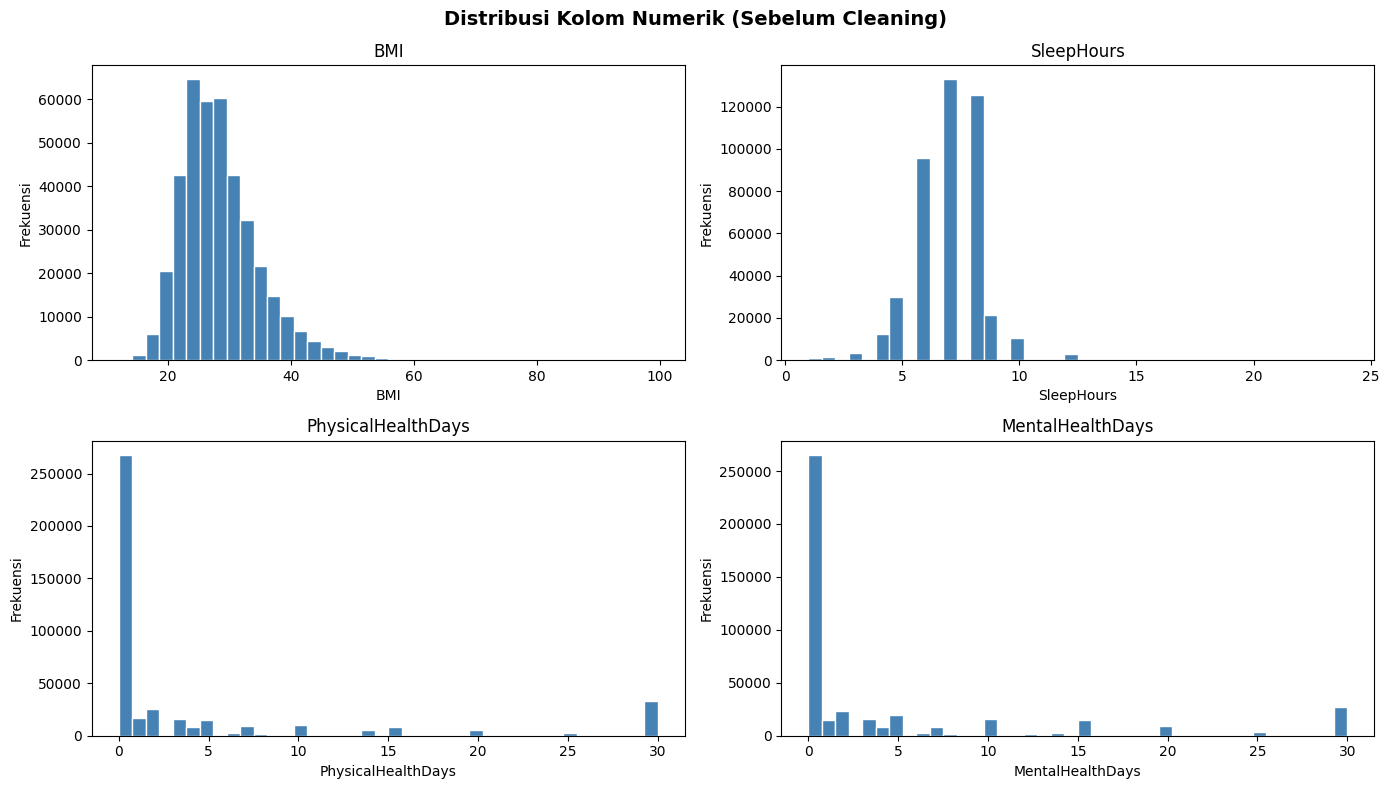

Gambar disimpan.


In [9]:
# Visualisasi distribusi kolom numerik
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Distribusi Kolom Numerik (Sebelum Cleaning)', fontsize=14, fontweight='bold')

for ax, col in zip(axes.flatten(), numeric_cols):
    if col in df.columns:
        ax.hist(df[col].dropna(), bins=40, color='steelblue', edgecolor='white')
        ax.set_title(col)
        ax.set_xlabel(col)
        ax.set_ylabel('Frekuensi')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'numeric_distribution_before_cleaning.png', dpi=150)
plt.show()
print('Gambar disimpan.')

=== DISTRIBUSI TARGET VARIABLE: HadHeartAttack ===
                 Count      %
HadHeartAttack               
No              416959  94.32
Yes              25108   5.68


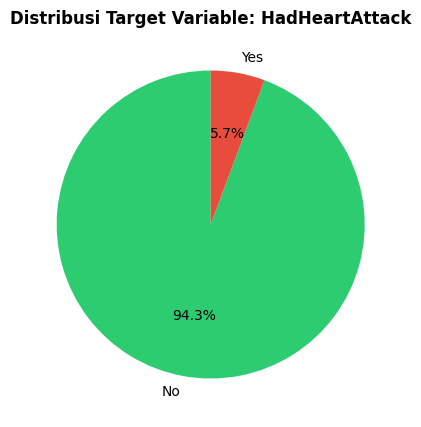


CATATAN: Class imbalance terdeteksi. Kelas positif (HadHeartAttack=Yes) hanya 5.7% dari total data.


In [10]:
# --- 2.4 Distribusi Target Variable ---
target = 'HadHeartAttack'
print(f'=== DISTRIBUSI TARGET VARIABLE: {target} ===')
target_dist = df[target].value_counts()
target_pct = df[target].value_counts(normalize=True) * 100
print(pd.DataFrame({'Count': target_dist, '%': target_pct.round(2)}))

# Pie chart class balance
fig, ax = plt.subplots(figsize=(6, 5))
ax.pie(target_dist, labels=target_dist.index, autopct='%1.1f%%',
       colors=['#2ecc71', '#e74c3c'], startangle=90)
ax.set_title('Distribusi Target Variable: HadHeartAttack', fontsize=12, fontweight='bold')
plt.savefig(FIGURES_DIR / 'target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nCATATAN: Class imbalance terdeteksi. Kelas positif ({target}=Yes) hanya {target_pct.get("Yes", 0):.1f}% dari total data.')

In [11]:
# --- 2.5 Inkonsistensi nilai kategorik ---
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'=== NILAI UNIK KOLOM KATEGORIK ===')
for col in cat_cols[:15]:  # tampilkan 15 pertama
    unique_vals = df[col].dropna().unique()
    print(f'{col:30s}: {sorted(unique_vals)}')

=== NILAI UNIK KOLOM KATEGORIK ===
State                         : ['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado', 'Connecticut', 'Delaware', 'District of Columbia', 'Florida', 'Georgia', 'Guam', 'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 'North Carolina', 'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Puerto Rico', 'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas', 'Utah', 'Vermont', 'Virgin Islands', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming']
Sex                           : ['Female', 'Male']
GeneralHealth                 : ['Excellent', 'Fair', 'Good', 'Poor', 'Very good']
LastCheckupTime               : ['5 or more years ago', 'Within past 2 years (1 year but less than 2 years ago)

---
## Step 3: Cleaning Data
Membersihkan data sesuai urutan yang telah ditentukan.

In [12]:
df_clean = df.copy()
print(f'Shape awal: {df_clean.shape}')

Shape awal: (445132, 40)


In [13]:
# --- 3.1 Drop kolom dengan missing values > 15% ---
# TetanusLast10Tdap (18.5%) dan PneumoVaxEver (17.3%) tidak relevan langsung
# dengan gaya hidup/risiko jantung, drop sesuai panduan
cols_to_drop = []
for col in df_clean.columns:
    pct = df_clean[col].isnull().sum() / len(df_clean) * 100
    if pct > 15:
        cols_to_drop.append(col)
        print(f'DROP: {col} ({pct:.1f}% missing)')

df_clean.drop(columns=cols_to_drop, inplace=True)
print(f'\nShape setelah drop kolom: {df_clean.shape}')

DROP: PneumoVaxEver (17.3% missing)
DROP: TetanusLast10Tdap (18.5% missing)

Shape setelah drop kolom: (445132, 38)


In [14]:
# --- 3.2 Handle missing values ---

# Kolom numerik: isi dengan median
num_cols_with_na = df_clean.select_dtypes(include='number').columns[
    df_clean.select_dtypes(include='number').isnull().any()
]
for col in num_cols_with_na:
    median_val = df_clean[col].median()
    df_clean[col].fillna(median_val, inplace=True)
    print(f'Numerik [{col}]: diisi dengan median = {median_val:.2f}')

# Kolom kategorik: isi dengan modus
cat_cols_with_na = df_clean.select_dtypes(include='object').columns[
    df_clean.select_dtypes(include='object').isnull().any()
]
for col in cat_cols_with_na:
    mode_val = df_clean[col].mode()[0]
    df_clean[col].fillna(mode_val, inplace=True)
    print(f'Kategorik [{col}]: diisi dengan modus = "{mode_val}"')

print(f'\nTotal missing values setelah imputasi: {df_clean.isnull().sum().sum()}')

Numerik [PhysicalHealthDays]: diisi dengan median = 0.00
Numerik [MentalHealthDays]: diisi dengan median = 0.00
Numerik [SleepHours]: diisi dengan median = 7.00
Numerik [HeightInMeters]: diisi dengan median = 1.70
Numerik [WeightInKilograms]: diisi dengan median = 80.74
Numerik [BMI]: diisi dengan median = 27.44
Kategorik [GeneralHealth]: diisi dengan modus = "Very good"
Kategorik [LastCheckupTime]: diisi dengan modus = "Within past year (anytime less than 12 months ago)"
Kategorik [PhysicalActivities]: diisi dengan modus = "Yes"
Kategorik [RemovedTeeth]: diisi dengan modus = "None of them"
Kategorik [HadHeartAttack]: diisi dengan modus = "No"
Kategorik [HadAngina]: diisi dengan modus = "No"
Kategorik [HadStroke]: diisi dengan modus = "No"
Kategorik [HadAsthma]: diisi dengan modus = "No"
Kategorik [HadSkinCancer]: diisi dengan modus = "No"
Kategorik [HadCOPD]: diisi dengan modus = "No"
Kategorik [HadDepressiveDisorder]: diisi dengan modus = "No"
Kategorik [HadKidneyDisease]: diisi deng

In [15]:
# --- 3.3 Handle outlier dengan IQR method (capping/winsorizing) ---
numeric_cols_to_cap = ['BMI', 'SleepHours', 'PhysicalHealthDays', 'MentalHealthDays']

for col in numeric_cols_to_cap:
    if col in df_clean.columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        before = df_clean[(df_clean[col] < lower) | (df_clean[col] > upper)].shape[0]
        df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)
        print(f'[{col}]: {before} outlier di-cap ke range [{lower:.2f}, {upper:.2f}]')

[BMI]: 19007 outlier di-cap ke range [14.51, 40.91]
[SleepHours]: 7260 outlier di-cap ke range [3.00, 11.00]
[PhysicalHealthDays]: 72269 outlier di-cap ke range [-4.50, 7.50]
[MentalHealthDays]: 61769 outlier di-cap ke range [-6.00, 10.00]


In [16]:
# --- 3.4 Encoding kolom kategorik ---

# Binary Yes/No -> 1/0
yes_no_cols = [
    'PhysicalActivities', 'HadHeartAttack', 'HadAngina', 'HadStroke',
    'HadAsthma', 'HadCOPD', 'HadKidneyDisease', 'HadArthritis',
    'HadDiabetes', 'DeafOrHardOfHearing', 'BlindOrVisionDifficulty',
    'DifficultyConcentrating', 'DifficultyWalking', 'DifficultyDressingBathing',
    'DifficultyErrands', 'ChestScan', 'AlcoholDrinkers', 'HIVTesting',
    'FluVaxLast12', 'CovidPos', 'HighRiskLastYear'
]
for col in yes_no_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].map({'Yes': 1, 'No': 0})

# Ordinal encoding: GeneralHealth
health_map = {'Poor': 1, 'Fair': 2, 'Good': 3, 'Very good': 4, 'Excellent': 5}
if 'GeneralHealth' in df_clean.columns:
    df_clean['GeneralHealth'] = df_clean['GeneralHealth'].map(health_map)

# Ordinal encoding: AgeCategory
age_categories = sorted(df['AgeCategory'].dropna().unique())
age_map = {cat: i+1 for i, cat in enumerate(age_categories)}
if 'AgeCategory' in df_clean.columns:
    df_clean['AgeCategory'] = df_clean['AgeCategory'].map(age_map)
print('AgeCategory mapping:', age_map)

# Binary encoding: Sex
if 'Sex' in df_clean.columns:
    df_clean['Sex'] = df_clean['Sex'].map({'Male': 1, 'Female': 0})

# SmokerStatus encoding
smoker_map = {
    'Never smoked': 0,
    'Former smoker': 1,
    'Current smoker - now smokes some days': 2,
    'Current smoker - now smokes every day': 3
}
if 'SmokerStatus' in df_clean.columns:
    df_clean['SmokerStatus'] = df_clean['SmokerStatus'].map(smoker_map).fillna(0)

# ECigaretteUsage encoding
ecig_map = {
    'Never used e-cigarettes in my entire life': 0,
    'Not at all (right now)': 1,
    'Use them some days': 2,
    'Use them every day': 3
}
if 'ECigaretteUsage' in df_clean.columns:
    df_clean['ECigaretteUsage'] = df_clean['ECigaretteUsage'].map(ecig_map).fillna(0)

# RaceEthnicityCategory: one-hot encoding
if 'RaceEthnicityCategory' in df_clean.columns:
    race_dummies = pd.get_dummies(df_clean['RaceEthnicityCategory'], prefix='Race')
    df_clean = pd.concat([df_clean.drop(columns=['RaceEthnicityCategory']), race_dummies], axis=1)

# State: drop (terlalu banyak kategori, tidak relevan langsung)
if 'State' in df_clean.columns:
    df_clean.drop(columns=['State'], inplace=True)
    print('Kolom "State" di-drop (terlalu banyak kategori unik).')

# HadDiabetes: ada lebih dari 2 kategori, encode ordinal
if df_clean['HadDiabetes'].dtype == object:
    diabetes_map = {'No': 0, 'No, pre-diabetes or borderline diabetes': 1,
                    'Yes, but female told only during pregnancy': 2, 'Yes': 3}
    df_clean['HadDiabetes'] = df_clean['HadDiabetes'].map(diabetes_map).fillna(0)

print(f'\nShape setelah encoding: {df_clean.shape}')
print(f'Missing values tersisa: {df_clean.isnull().sum().sum()}')

AgeCategory mapping: {'Age 18 to 24': 1, 'Age 25 to 29': 2, 'Age 30 to 34': 3, 'Age 35 to 39': 4, 'Age 40 to 44': 5, 'Age 45 to 49': 6, 'Age 50 to 54': 7, 'Age 55 to 59': 8, 'Age 60 to 64': 9, 'Age 65 to 69': 10, 'Age 70 to 74': 11, 'Age 75 to 79': 12, 'Age 80 or older': 13}
Kolom "State" di-drop (terlalu banyak kategori unik).

Shape setelah encoding: (445132, 41)
Missing values tersisa: 27601


In [17]:
# Handle any remaining missing values or non-numeric columns
remaining_na = df_clean.isnull().sum()
remaining_na = remaining_na[remaining_na > 0]
if len(remaining_na) > 0:
    print('Kolom dengan missing values tersisa:')
    print(remaining_na)
    # Fill numeric with median, object with mode
    for col in remaining_na.index:
        if df_clean[col].dtype in ['float64', 'int64']:
            df_clean[col].fillna(df_clean[col].median(), inplace=True)
        else:
            df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)
else:
    print('Tidak ada missing values tersisa.')

# Handle remaining object columns (if any)
obj_cols = df_clean.select_dtypes(include='object').columns.tolist()
if obj_cols:
    print(f'\nKolom object yang tersisa: {obj_cols}')
    for col in obj_cols:
        df_clean[col] = pd.Categorical(df_clean[col]).codes
        print(f'  [{col}] di-encode dengan label encoding.')
else:
    print('Semua kolom sudah numerik.')

print(f'\nFinal shape: {df_clean.shape}')
print(f'Total missing: {df_clean.isnull().sum().sum()}')

Kolom dengan missing values tersisa:
HadDiabetes    14165
CovidPos       13436
dtype: int64

Kolom object yang tersisa: ['LastCheckupTime', 'RemovedTeeth', 'HadSkinCancer', 'HadDepressiveDisorder']
  [LastCheckupTime] di-encode dengan label encoding.
  [RemovedTeeth] di-encode dengan label encoding.
  [HadSkinCancer] di-encode dengan label encoding.
  [HadDepressiveDisorder] di-encode dengan label encoding.

Final shape: (445132, 41)
Total missing: 0


In [18]:
# --- 3.5 Simpan hasil cleaning ---
df_clean.to_csv(PROCESSED_DATA_PATH, index=False)
print(f'Dataset cleaned disimpan ke: {PROCESSED_DATA_PATH}')
print(f'Shape final: {df_clean.shape}')
print(f'\nPreview dataset cleaned:')
df_clean.head()

Dataset cleaned disimpan ke: ..\data\processed\dataset_cleaned.csv
Shape final: (445132, 41)

Preview dataset cleaned:


,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,HadAngina,...,AlcoholDrinkers,HIVTesting,FluVaxLast12,HighRiskLastYear,CovidPos,"Race_Black only, Non-Hispanic",Race_Hispanic,"Race_Multiracial, Non-Hispanic","Race_Other race only, Non-Hispanic","Race_White only, Non-Hispanic"
0,0,4,0.0,0.0,3,0,8.0,3,0,0,...,0,0,1,0,0.0,False,False,False,False,True
1,0,5,0.0,0.0,3,0,6.0,3,0,0,...,0,0,0,0,0.0,False,False,False,False,True
2,0,4,2.0,3.0,3,1,5.0,3,0,0,...,0,0,0,0,1.0,False,False,False,False,True
3,0,5,0.0,0.0,3,1,7.0,3,0,0,...,0,0,1,0,0.0,False,False,False,False,True
4,0,2,2.0,0.0,3,1,9.0,3,0,0,...,1,0,0,0,0.0,False,False,False,False,True


In [19]:
# Summary cleaning report
print('=== RINGKASAN DATA WRANGLING ===')
print(f'Shape awal  : {df.shape}')
print(f'Shape akhir : {df_clean.shape}')
print(f'Kolom di-drop: {set(df.columns) - set(df_clean.columns) - set([c for c in df_clean.columns if c not in df.columns])}')
print(f'Missing values awal : {df.isnull().sum().sum():,}')
print(f'Missing values akhir: {df_clean.isnull().sum().sum():,}')
print(f'Target variable (HadHeartAttack):')
print(f'  0 (No) : {(df_clean["HadHeartAttack"]==0).sum():,} ({(df_clean["HadHeartAttack"]==0).mean()*100:.1f}%)')
print(f'  1 (Yes): {(df_clean["HadHeartAttack"]==1).sum():,} ({(df_clean["HadHeartAttack"]==1).mean()*100:.1f}%)')

=== RINGKASAN DATA WRANGLING ===
Shape awal  : (445132, 40)
Shape akhir : (445132, 41)
Kolom di-drop: {'RaceEthnicityCategory', 'State', 'TetanusLast10Tdap', 'PneumoVaxEver'}
Missing values awal : 902,665
Missing values akhir: 0
Target variable (HadHeartAttack):
  0 (No) : 420,024 (94.4%)
  1 (Yes): 25,108 (5.6%)
